# HA-SSJs in Life-Cycle Models

In [1]:
# Basic imports
from HARK.models import IndShockConsumerType
from HARK.utilities import plot_SSJ
from HARK.ConsumptionSaving.ConsIndShockModel import init_lifecycle
from time import time

mystr = lambda x: "{:.3f}".format(x)

The "sequence space Jacobian" approach, first [described by Auclert et al (2021)](https://onlinelibrary.wiley.com/doi/full/10.3982/ECTA17434), has rapidly become quite popular in heterogeneous agents macroeconomics. While the original paper only laid out how to construct HA-SSJ matrices (with the "fake news" algorithm) for standard infinite horizon or perpetual youth models, one of its authors has very recently teamed up with friend of Econ-ARK Velasquez-Giraldo to [extend the algorithm](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5274675) to life-cycle models.

This new HA-SSJ capability for life-cycle models has been incorporated into HARK, using the same `make_basic_SSJ` interface as for standard infinite horizon models. If you haven't already, we recommend that you read our [basic SSJ tutorial](SSJ-tutorial.ipynb) notebook before going further here.

## Additional Options for Life-Cycle Models

The basic syntax for using `make_basic_SSJ` is the same for a life-cycle model as for a standard infinite horizon model. If you have an instance of an `AgentType` subclass named `Agent`, then you can do:

`SSJs = Agent.make_basic_SSJ(shock, outcomes, grids)`

The `shock` names a single age-varying model parameters that (directly or indirectly) affects the life-cycle problem (the $x$), and the `outcomes` are the names of one or more more model variables whose effects we are interested in (the $Y$s).

Just like with an infinite horizon model, you can optionally name a Harmenberg `norm` to more efficiently handle permanent income normalization (and thus skip providing a grid for `pLvl`). For most permanent-income-normalized models in HARK, this is `PermShk`.

**NB:** Please see the basic tutorial notebook for additional options that are also available for life-cycle models.

Whether or not you use the "Harmenberg trick" in a permanent-income-normalized model, you *must* name the normalization `trend` if one exists. In most normalized HARK models, permanent income growth has an expected value in each period given by `PermGroFac`, so you would pass `trend="PermGroFac"` to `make_basic_SSJ`. Failing to do this will result in the HA-SSJ output being incorrectly weighted by age and thus wrong.

If there is ongoing population growth, so that each successive cohort is $P$ times the size of the prior one, then the value of $P$ should be passed as the `pop_gro` argument to the method. **NB:** This functionality is not yet implemented.

If there is ongoing productivity growth, so that the *level* of each successive cohort's variables (at model entry) grows by factor $G$ relative to the prior cohort, then the value of $G$ should be passed as the `prod_gro` argument to the method. **NB:** This functionality is not yet implemented.

If you wish to examine the age-specific HA-SSJ matrices (i.e. you do not want the output to be summed across ages), then you should pass `age_agg=False` to the method.

## Example Life-Cycle HA-SSJ

As in the basic tutorial, we will use HARK's workhorse `IndShockConsumerType` as our example model, but with an off-the-shelf life-cycle dictionary. The details don't really matter, but the dictionary `init_lifecycle` represents high-school-educated men who enter the model at age 25, live to age 90 at most, and have an income process as estimated by Cagetti (2003) for growth factors and Sabelhaus and Song (2010) for income risk.

In [2]:
# Make a life-cycle agent using an off-the-shelf dictionary
MyType = IndShockConsumerType(**init_lifecycle)

As usual, we need to specify grids for state variables. Continuous variables need at least a `min` and a `max`, as well as a number of gridpoints `N`. By default, linear spacing is used, but you can set a polynomial `order` or a level of exponential nesting as `nest`. Alternatively, you can specify a custom grid in the `custom` key. For a discrete state, only the number of values `N` needs to be given.

You must provide a grid for all arrival variables (other than the one that is normalized out, if you use `norm`), as well as for any `outcome` variables that are requested. The exception is for an `outcome` that `twist`s to an arrival variable. E.g., `aNrm[t] --> kNrm[t+1]` in many HARK models, so you do not need to provide a grid for `aNrm` once the grid for (arrival variable) `kNrm` has been provided.

In [3]:
# Define grid specifications
wealth_grid = {"min": 0.0, "max": 40.0, "N": 250, "order": 2.0}
con_grid = {"min": 0.0, "max": 10.0, "N": 201}
my_grid_specs = {"kNrm": wealth_grid, "cNrm": con_grid}

That's all of the setup we need to do! Let's construct the HA-SSJs with respect to the interest factor `Rfree`.

Because HARK's solver for `IndShockConsumerType` treats `Rfree[t]` as representing *next* period's interest rate (when computing expectations over future states), we need to designate the shock as `offset=True` so that the timing is parsed correctly.

We will use the "Harmenberg trick" with `PermShk` as the shock to be renormalized in the probability measure, so `norm="PermShk"` is also passed.

Finally, permanent income grows by factor `PermGroFac` each period, so we specify that `trend="PermGroFac"` to ensure proper weighting by age.

About 9-10 times more periods need to be solved and then converted to grid/matrix format for a life-cycle model as compared to an infinite horizon HA-SSJ construction, so this method will take about 50 seconds to run.

In [4]:
# Make HA-SSJs for the life-cycle model
t0 = time()
J_A_R, J_C_R = MyType.make_basic_SSJ(
    "Rfree",  # name of the parameter to be shocked
    ["aNrm", "cNrm"],  # name(s) of the outcome variable(s) we're interested in
    my_grid_specs,  # dictionary of grid specifications
    offset=True,
    norm="PermShk",
    trend="PermGroFac",
)
t1 = time()

print(
    "Constructing those HA-SSJs for a life-cycle model took "
    + mystr(t1 - t0)
    + " seconds."
)

Constructing those HA-SSJs for a life-cycle model took 49.344 seconds.


We can now plot the SSJs for assets and consumption with respect to the interest rate. They look an awful lot like the ones from the infinite horizon example, and that's no coincidence!

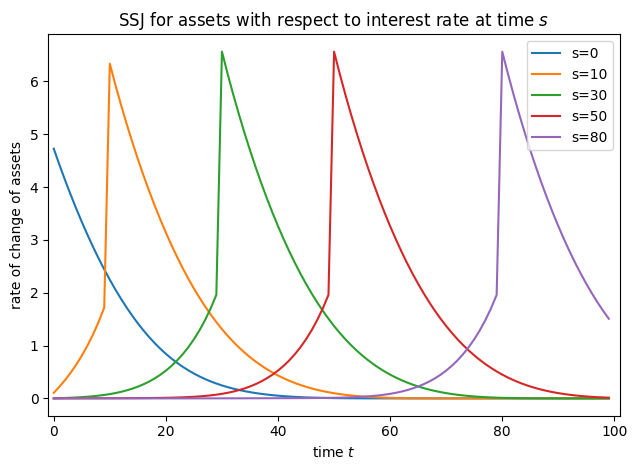

In [5]:
# Plot select columns of the HA-SSJs
plot_SSJ(J_A_R, [0, 10, 30, 50, 80], "assets", "interest rate")
plot_SSJ(J_C_R, [0, 10, 30, 50, 80], "consumption", "interest rate")

The outcomes are calculated as **population averages**, and thus the rate of change of the outcomes should also be interpreted this way. This is the major reason why the life-cycle algorithm is restricted to "flat" population dynamics, so that the level of the outcomes can be specified analogously to the infinite horizon model. In the presence of endogenous population dynamics (through agent behavior or through shocks), regularizing by population size must be handled a bit differently. This is an area of near future development in HARK.